# SECOM Dataset — Exploratory Data Analysis

**Project:** Yield Prediction in Semiconductor Manufacturing  
**Date:** August 12, 2026  
**Purpose:** Understand the structure, quality, and statistical properties
of the SECOM dataset before any modeling decisions are made.

**Research question:** Which process variables in a semiconductor manufacturing
line are most predictive of yield failure, and how does missing data and
class imbalance affect our ability to answer this question?


## Load Data

Load the feature matrix and label vector. SECOM has no header row —
each column represents a process sensor or measurement point.
Note: this version of the dataset contains 590 features
(some sources cite 591 — minor version difference).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
# SECOM has no header row — columns are process sensors/measurements
X = pd.read_csv('../data/raw/secom.data', sep=r'\s+', header=None, engine='python')
y_raw = pd.read_csv('../data/raw/secom_labels.data', 
                     sep=' ', header=None, names=['label', 'timestamp'])

print(f"Feature matrix shape: {X.shape}")
print(f"Label vector shape: {y_raw.shape}")

Feature matrix shape: (1567, 590)
Label vector shape: (1567, 2)


The dataset contains 1,567 observations and 591 features. 
Each row is one production lot; each column is one sensor measurement 
or process parameter recorded during manufacturing

In [3]:
y = y_raw['label']
print(f"Label distribution:")
print(y.value_counts())
print(f"Failure rate: {(y == 1).sum() / len(y) * 100:.2f}%")

Label distribution:
label
-1    1463
 1     104
Name: count, dtype: int64
Failure rate: 6.64%


In [4]:
# Examine missing data — tcritical for SECOM
missing_per_column = X.isnull().sum()
missing_percentage = (missing_per_column / len(X)) * 100

print(f"Columns with any missing data: {(missing_per_column > 0).sum()}")
print(f"Columns with >50% missing: {(missing_percentage > 50).sum()}")
print(f"Columns with >90% missing: {(missing_percentage > 90).sum()}")
print(f"\nTotal missing values: {X.isnull().sum().sum()}")
print(f"Overall missing rate: {X.isnull().sum().sum() / X.size * 100:.2f}%")

Columns with any missing data: 538
Columns with >50% missing: 28
Columns with >90% missing: 4

Total missing values: 41951
Overall missing rate: 4.54%


## Missing Data Visualization
Printing summary statistics alone is insufficient — knowing that 538 columns  have missing data does not tell us how missingness is distributed across ranges. 
A histogram will show us whether most columns cluster near 0% missing or are spread across the full range, which determines our imputation and dropping strategy.

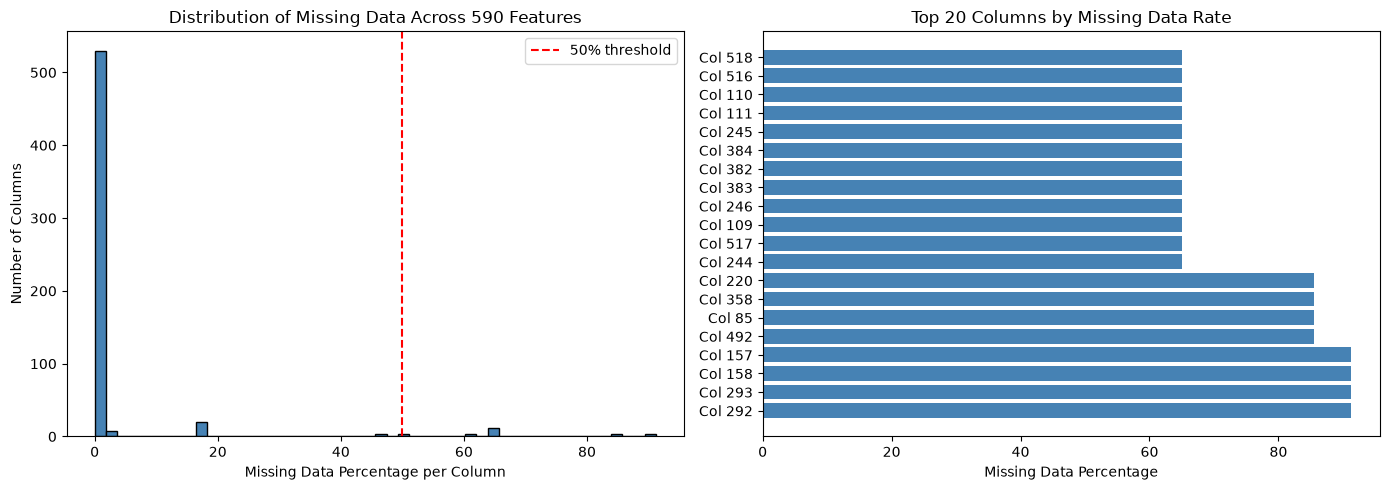

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(missing_percentage, bins=50, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Missing Data Percentage per Column')
axes[0].set_ylabel('Number of Columns')
axes[0].set_title('Distribution of Missing Data Across 590 Features')
axes[0].axvline(x=50, color='red', linestyle='--', label='50% threshold')
axes[0].legend()

top_missing = missing_percentage.sort_values(ascending=False).head(20)
axes[1].barh(range(20), top_missing.values, color='steelblue')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([f'Col {i}' for i in top_missing.index])
axes[1].set_xlabel('Missing Data Percentage')
axes[1].set_title('Top 20 Columns by Missing Data Rate')

plt.tight_layout()
plt.savefig('../reports/figures/missing_data_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
## Basic statistical summary
print("Statistical summary (first 10 columns):")
print(X.iloc[:, :10].describe().round(3))

# Check for zero-variance columns (useless features)
variances = X.var()
zero_variance_cols = (variances == 0).sum()
near_zero_variance_cols = (variances < 0.001).sum()

print(f"\nZero variance columns: {zero_variance_cols}")
print(f"Near-zero variance columns (<0.001): {near_zero_variance_cols}")

Statistical summary (first 10 columns):
              0         1         2         3         4       5         6  \
count  1561.000  1560.000  1553.000  1553.000  1553.000  1553.0  1553.000   
mean   3014.453  2495.850  2200.547  1396.377     4.197   100.0   101.113   
std      73.622    80.408    29.513   441.692    56.356     0.0     6.237   
min    2743.240  2158.750  2060.660     0.000     0.682   100.0    82.131   
25%    2966.260  2452.248  2181.044  1081.876     1.018   100.0    97.920   
50%    3011.490  2499.405  2201.067  1285.214     1.317   100.0   101.512   
75%    3056.650  2538.822  2218.056  1591.224     1.526   100.0   104.587   
max    3356.350  2846.440  2315.267  3715.042  1114.537   100.0   129.252   

              7         8         9  
count  1558.000  1565.000  1565.000  
mean      0.122     1.463    -0.001  
std       0.009     0.074     0.015  
min       0.000     1.191    -0.053  
25%       0.121     1.411    -0.011  
50%       0.122     1.462    -0.001  


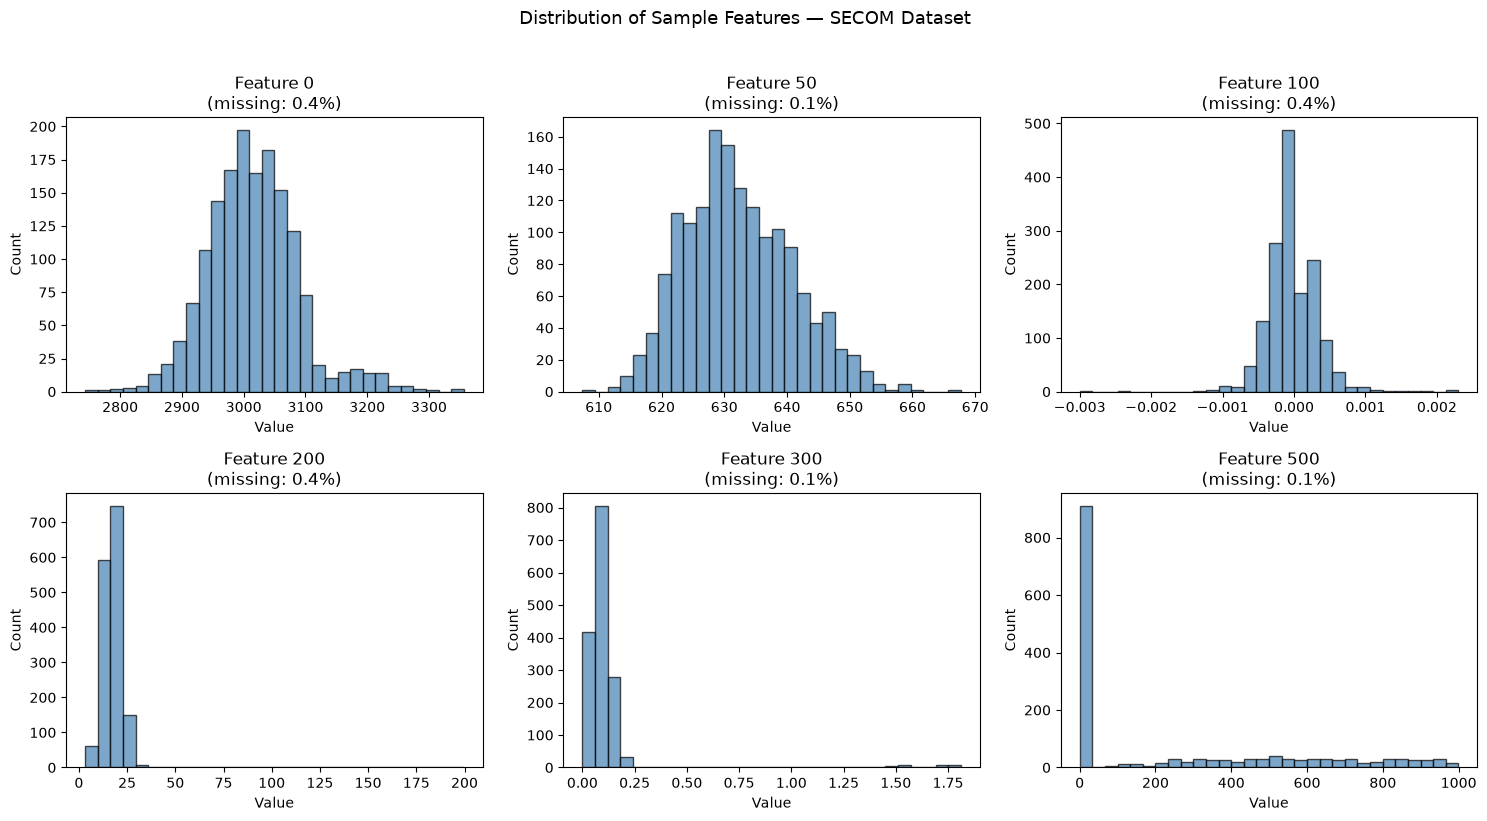

In [7]:
# Visualize the distribution of a sample of features
# Pick 6 columns with varying amounts of missing data to illustrate diversity
sample_cols = [0, 50, 100, 200, 300, 500]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(sample_cols):
    data = X.iloc[:, col].dropna()
    axes[idx].hist(data, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
    axes[idx].set_title(f'Feature {col}\n(missing: {missing_percentage[col]:.1f}%)')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Count')

plt.suptitle('Distribution of Sample Features — SECOM Dataset', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/feature_distributions_sample.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Compare feature distributions: pass vs. fail
# This is the core research question visualized directly
y_binary = (y == 1).astype(int)  # 1 = fail, 0 = pass

# Find columns with lowest missing rate for meaningful comparison
low_missing_cols = missing_percentage[missing_percentage < 10].index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(low_missing_cols):
    pass_data = X.loc[y_binary == 0, col].dropna()
    fail_data = X.loc[y_binary == 1, col].dropna()
    
    axes[idx].hist(pass_data, bins=30, alpha=0.6, color='green', 
                   label='Pass', density=True)
    axes[idx].hist(fail_data, bins=30, alpha=0.6, color='red', 
                   label='Fail', density=True)
    axes[idx].set_title(f'Feature {col}')
    axes[idx].set_xlabel('Value')
    axes[idx].legend()

plt.suptitle('Feature Distributions: Pass vs. Fail — SECOM Dataset', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/pass_fail_distributions.png', dpi=150, bbox_inches='tight')
plt.show()